# Homework 2

## Setup

In [31]:
library(stats)
library(repr)
library(tseries)
library(readr)
library(forecast)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



## Data Loading

In [8]:
#load the data
data_path <- "data/32990491/"

series_a <- read.csv(paste0(data_path, "series_A.csv"))
series_b <- read.csv(paste0(data_path, "series_B.csv"))
series_c <- read.csv(paste0(data_path, "series_C.csv"))
head(series_a)
colnames(series_a)

,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.012105493,0.0001669967
2,2,0.020492773,0.0001794689
3,3,0.003915982,0.0002313631
4,4,-0.007609600,0.0001995768
5,5,-0.014024501,0.0001883649
6,6,-0.001147900,0.0002003627


[1] "t"           "ret"         "sigma2_true"

## Problem 1: Preliminary analysis

### Datasets: Returns

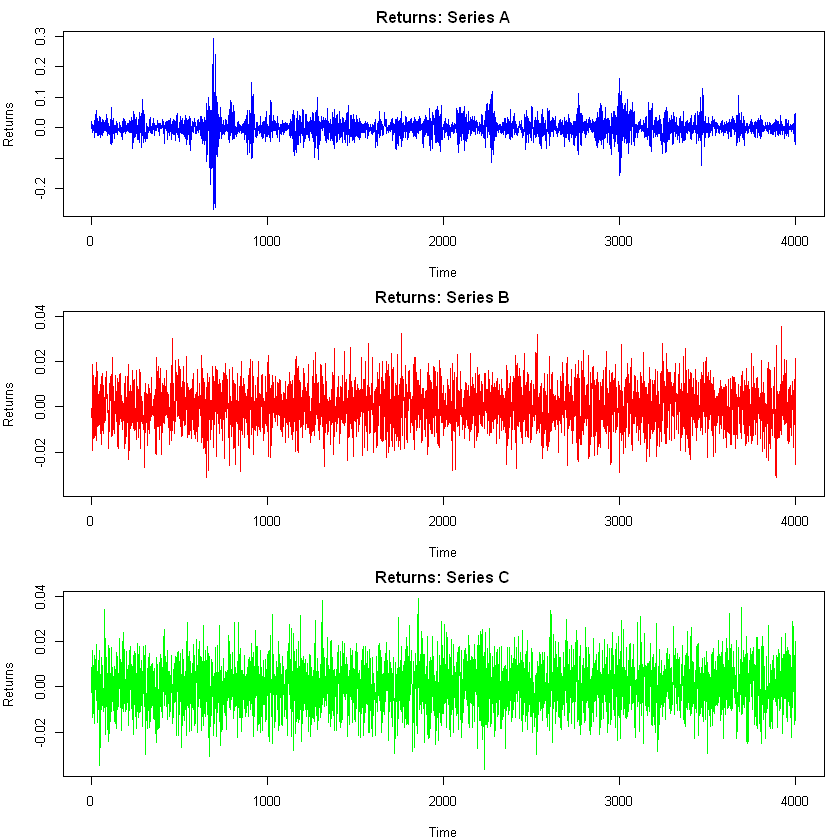

In [25]:
y_limits <- range(c(series_b$ret, series_c$ret), na.rm = TRUE)
par(mfrow=c(3,1), mar=c(4,4,2,1))

#Plot the returns using the shared y_limits
plot(series_a$ret, type = "l", col = "blue", 
     main = "Returns: Series A", 
     xlab = "Time", ylab = "Returns")

plot(series_b$ret, type = "l", col = "red", 
     main = "Returns: Series B", 
     xlab = "Time", ylab = "Returns",
     ylim = y_limits)

plot(series_c$ret, type = "l", col = "green", 
     main = "Returns: Series C", 
     xlab = "Time", ylab = "Returns",
     ylim = y_limits)

### Datasets: Squared Returns

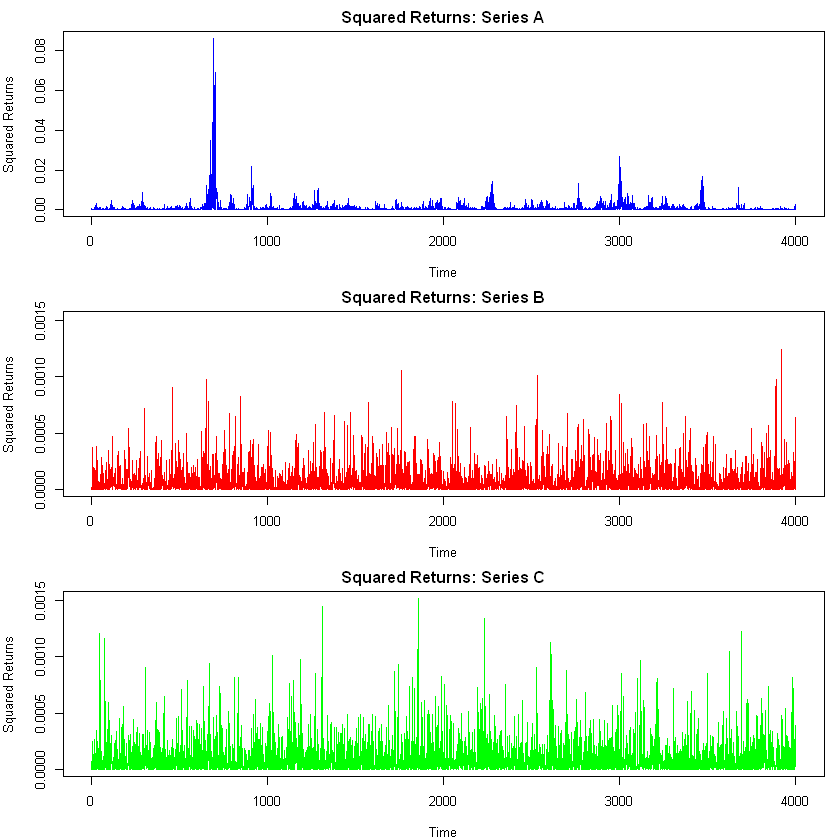

In [26]:
y_limits_bc <- range(c((series_b$ret)^2, (series_c$ret)^2), na.rm = TRUE)
par(mfrow=c(3,1), mar=c(4,4,2,1))
plot((series_a$ret)^2, type = "l", col = "blue", 
     main = "Squared Returns: Series A", 
     xlab = "Time", ylab = "Squared Returns")

plot((series_b$ret)^2, type = "l", col = "red", 
     main = "Squared Returns: Series B", 
     xlab = "Time", ylab = "Squared Returns",
     ylim = y_limits_bc)

plot((series_c$ret)^2, type = "l", col = "green", 
     main = "Squared Returns: Series C", 
     xlab = "Time", ylab = "Squared Returns",
     ylim = y_limits_bc)

### Initial Hypothesis on Volatility Clustering

Based on a visual inspection of the plots, it seems that Series A exhibits the most persistent volatility clustering, while Series B exhibits the least (likely none). This is justified by the behavior of both the raw and squared returns. For Series A, the graphs show massive, clearly defined, and long-lasting bursts of variance such as the extreme spikes around periods 750 and 3000, strongly indicating highly persistent GARCH-type effects where large shocks are followed by more large shocks. Conversely, Series B displays a highly uniform and consistent dispersion across the entire timeline. Its squared returns are evenly distributed without any distinct dense patches, suggesting a homoskedasticity with no clustering whatsoever. Finally, Series C appears to exhibit moderate persistence. When plotted on the same scale as Series B, its squared returns reveal subtle but distinct localized patches of elevated variance such as the denser clustering between periods 1000 and 2000, indicating that volatility shocks cluster but decay faster than in Series A.

## Problem 2: Identification of the conditional mean

### ACF and PACF of Returns

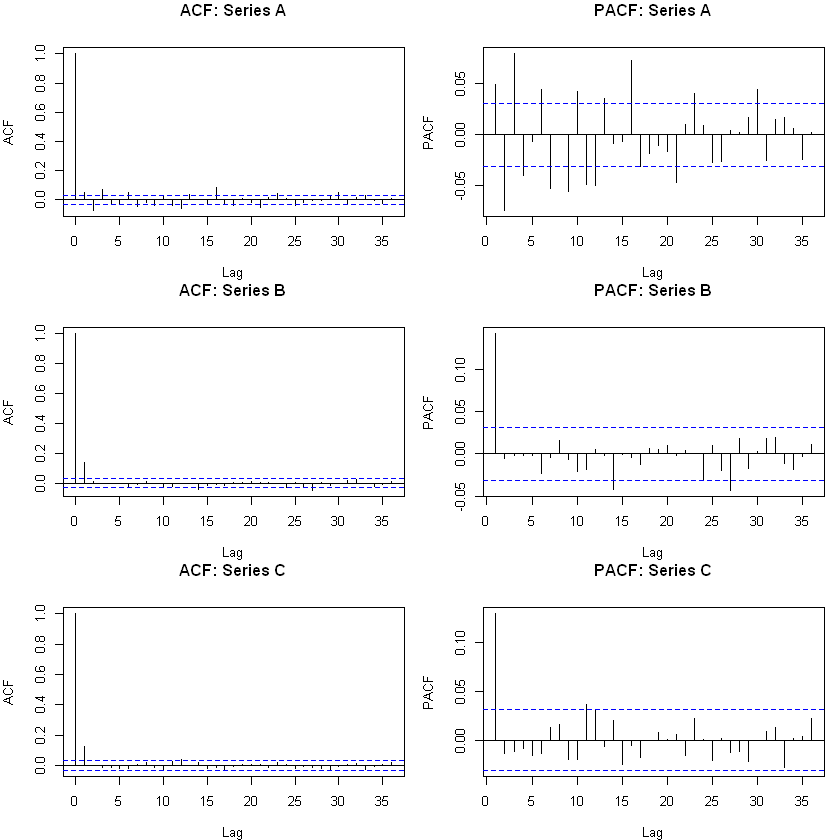

In [15]:
par(mfrow=c(3,2), mar=c(4,4,3,1))

# --- Series A ---
acf(series_a$ret, main="ACF: Series A", ylab="ACF")
pacf(series_a$ret, main="PACF: Series A", ylab="PACF")

# --- Series B ---
acf(series_b$ret, main="ACF: Series B", ylab="ACF")
pacf(series_b$ret, main="PACF: Series B", ylab="PACF")

# --- Series C ---
acf(series_c$ret, main="ACF: Series C", ylab="ACF")
pacf(series_c$ret, main="PACF: Series C", ylab="PACF")

### Plausible ARMA Specifications

#Series A
Specifications: ARMA(0,0), ARMA(1,0), ARMA(0,1)

Both the ACF and PACF show no statistically significant spikes beyond lag 0. The few marginal spikes in the PACF are on such a tiny scale (-0.05 to 0.05) that they represent statistical noise rather than a true pattern. This indicates the series is white noise, making ARMA(0,0) the primary candidate, with ARMA(1,0) and ARMA(0,1) as baselines to test.

#Series B
Specifications: ARMA(0,1), ARMA(1,0), ARMA(1,1)

The ACF shows a single significant spike at lag 1 before cutting off into the confidence bounds, which classically suggests an MA(1) process (ARMA(0,1)). However, the PACF also drops off quickly. Because the theoretical decay of financial data is often hidden within the confidence bands, this visual ambiguity means we must test pure MA, pure AR, and mixed models to be sure.

#Series C
Specifications: ARMA(1,0), ARMA(0,1), ARMA(1,1)

The PACF has a highly significant spike at lag 1 and then sharply cuts off, which is the textbook signature of an AR(1) process (ARMA(1,0)). Similar to Series B, the expected decay in the ACF is lost within the confidence bounds due to small coefficients. 

### Estimation of Candidate ARMA Models and Residual Diagnostics

Series: series_a$ret 
ARIMA(0,0,0) with non-zero mean 

Coefficients:
       mean
      5e-04
s.e.  5e-04

sigma^2 = 0.0009428:  log likelihood = 8258.08
AIC=-16512.17   AICc=-16512.16   BIC=-16499.58

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE     MASE
Training set 1.250269e-15 0.03070102 0.02095631 287.6779 293.9804 0.754538
                   ACF1
Training set 0.04883591

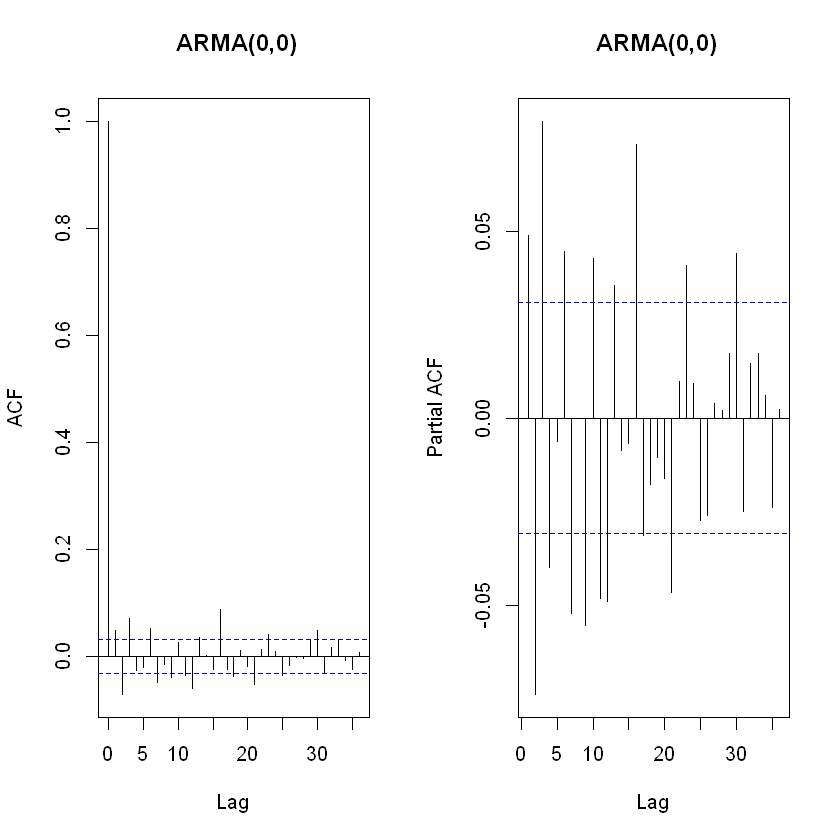

In [70]:
#Series A
# 1. ARMA(0,0) - White Noise
model_A_00 <- Arima(series_a$ret, order = c(0, 0, 0))
summary(model_A_00)
par(mfrow=c(1,2))
acf(model_A_00$residuals, main = " ARMA(0,0)")
pacf(model_A_00$residuals, main = " ARMA(0,0)")


Series: series_a$ret 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
         ar1   mean
      0.0488  5e-04
s.e.  0.0158  5e-04

sigma^2 = 0.0009408:  log likelihood = 8262.86
AIC=-16519.72   AICc=-16519.71   BIC=-16500.83

Training set error measures:
                       ME       RMSE        MAE     MPE     MAPE      MASE
Training set 3.974996e-08 0.03066438 0.02090567 366.803 375.8829 0.7527149
                    ACF1
Training set 0.003620761

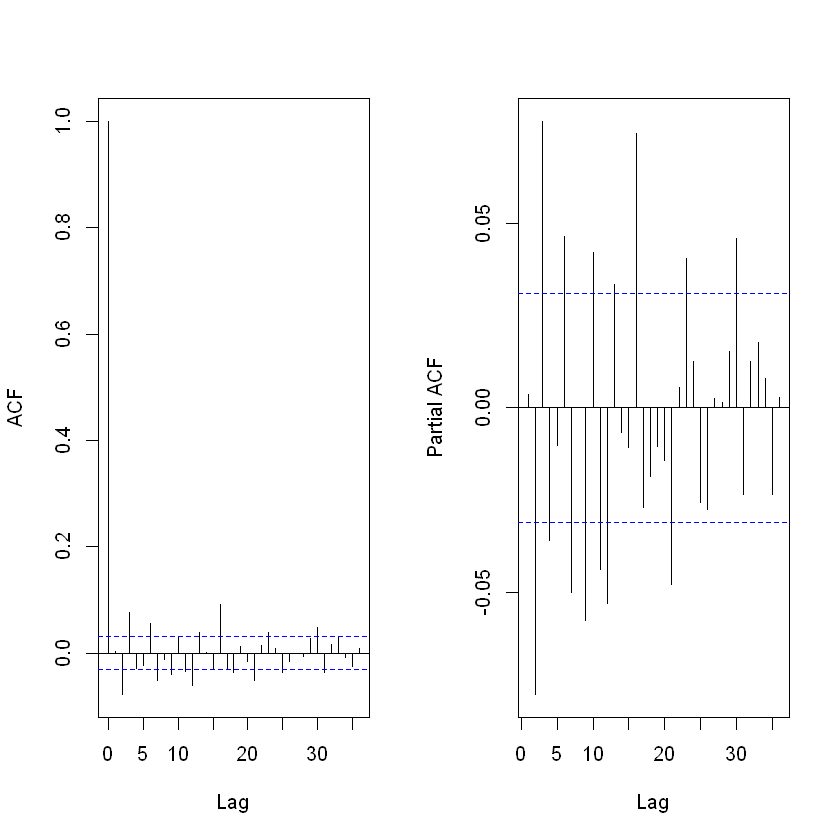

In [56]:
# 2. ARMA(1,0) - AR(1)
model_A_10 <- Arima(series_a$ret, order = c(1, 0, 0))
summary(model_A_10)
par(mfrow = c(1, 2))
acf(model_A_10$residuals, main = NA)
pacf(model_A_10$residuals, main = NA)



Series: series_a$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
         ma1   mean
      0.0580  5e-04
s.e.  0.0173  5e-04

sigma^2 = 0.0009404:  log likelihood = 8263.73
AIC=-16521.46   AICc=-16521.45   BIC=-16502.57

Training set error measures:
                        ME       RMSE       MAE      MPE     MAPE      MASE
Training set -1.605255e-07 0.03065771 0.0208973 373.8759 384.4586 0.7524134
                     ACF1
Training set -0.004637656

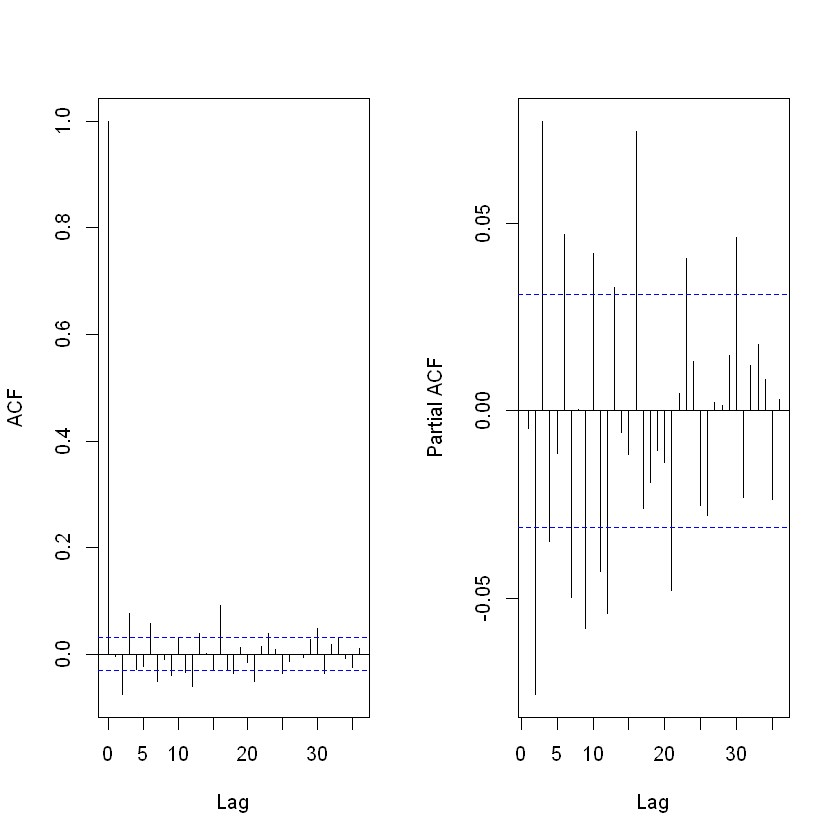

In [57]:
# 3. ARMA(0,1) - MA(1)
model_A_01 <- Arima(series_a$ret, order = c(0, 0, 1))
summary(model_A_01)
par(mfrow = c(1, 2))
acf(model_A_01$residuals, main = NA)
pacf(model_A_01$residuals, main = NA)



Series: series_b$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
         ma1   mean
      0.1402  0e+00
s.e.  0.0154  2e-04

sigma^2 = 8.223e-05:  log likelihood = 13137.3
AIC=-26268.6   AICc=-26268.59   BIC=-26249.72

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE     MASE
Training set 2.421213e-07 0.00906562 0.007232109 105.0772 145.6999 0.766935
                    ACF1
Training set 0.002150541

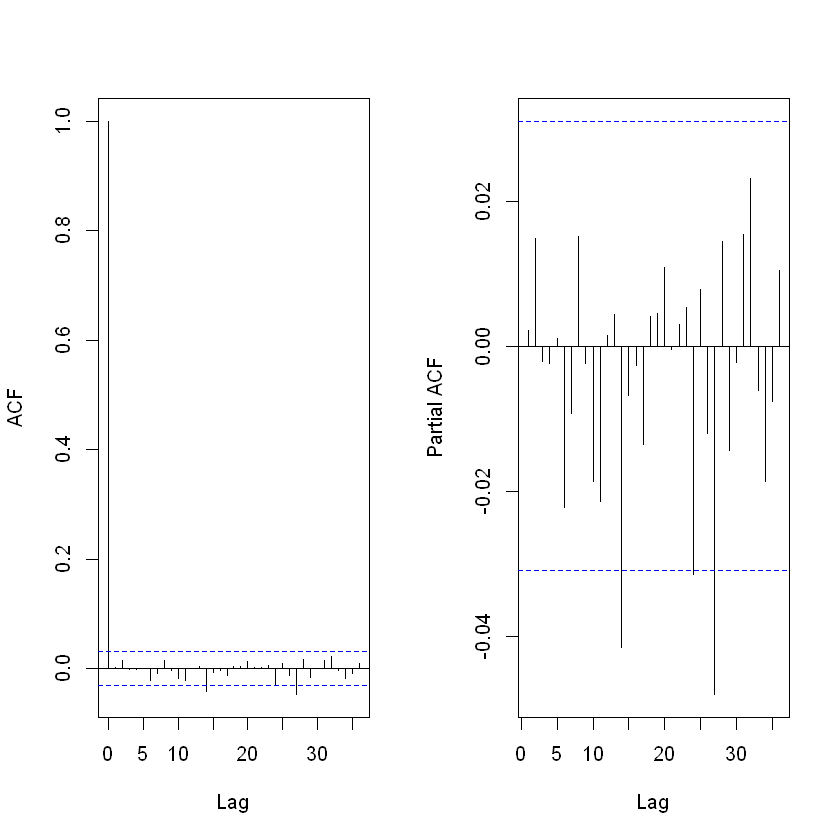

In [60]:
#Series B
# 1. ARMA(0,1) - MA(1) (Primary Candidate)
model_B_01 <- Arima(series_b$ret, order = c(0, 0, 1))
summary(model_B_01)
par(mfrow = c(1, 2))
acf(model_B_01$residuals, main = NA)
pacf(model_B_01$residuals, main = NA)



Series: series_b$ret 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
         ar1   mean
      0.1416  0e+00
s.e.  0.0157  2e-04

sigma^2 = 8.221e-05:  log likelihood = 13137.7
AIC=-26269.4   AICc=-26269.39   BIC=-26250.52

Training set error measures:
                       ME        RMSE         MAE      MPE     MAPE      MASE
Training set 3.116411e-07 0.009064716 0.007230985 106.3331 148.2757 0.7668158
                     ACF1
Training set 0.0007835188

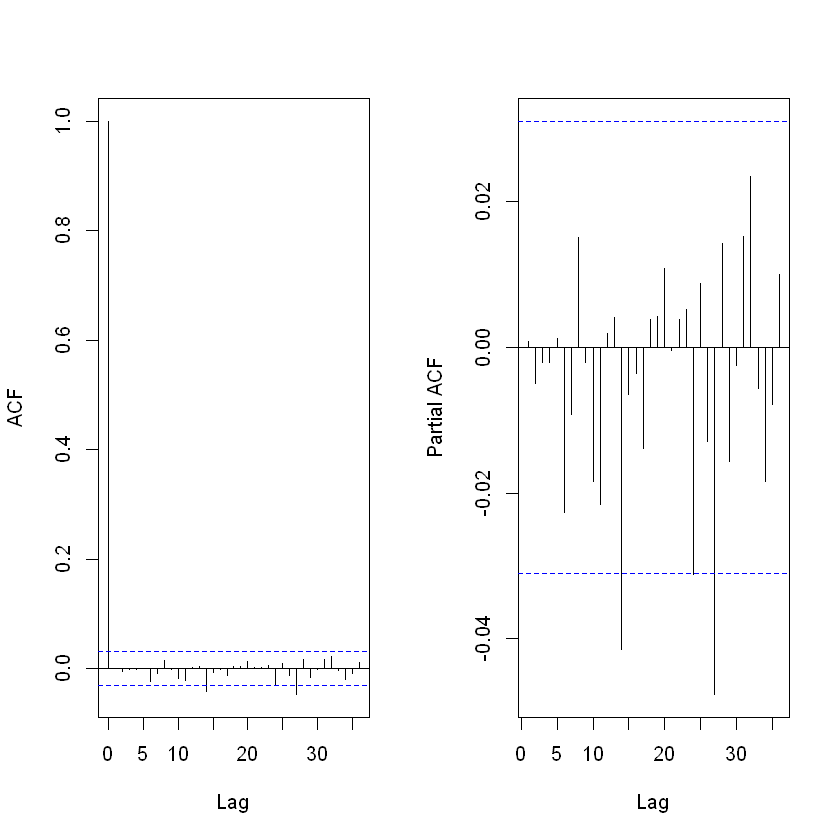

In [61]:
# 2. ARMA(1,0) - AR(1) 
model_B_10 <- Arima(series_b$ret, order = c(1, 0, 0))
summary(model_B_10)
par(mfrow = c(1, 2))
acf(model_B_10$residuals, main = NA)
pacf(model_B_10$residuals, main = NA)



Series: series_b$ret 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
         ar1     ma1   mean
      0.1060  0.0363  0e+00
s.e.  0.1096  0.1101  2e-04

sigma^2 = 8.223e-05:  log likelihood = 13137.75
AIC=-26267.51   AICc=-26267.5   BIC=-26242.33

Training set error measures:
                        ME        RMSE         MAE      MPE     MAPE      MASE
Training set -1.158054e-06 0.009064591 0.007231257 106.1041 148.0457 0.7668446
                     ACF1
Training set 6.932297e-05

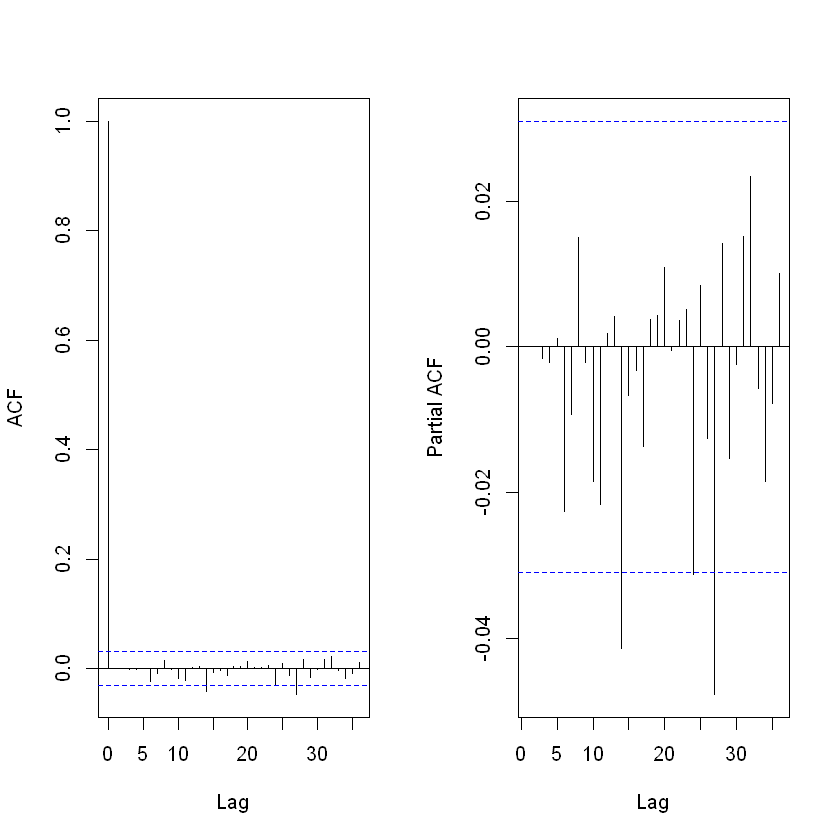

In [62]:
# 3. ARMA(1,1) - Mixed
model_B_11 <- Arima(series_b$ret, order = c(1, 0, 1))
summary(model_B_11)
par(mfrow = c(1, 2))
acf(model_B_11$residuals, main = NA)
pacf(model_B_11$residuals, main = NA)



Series: series_c$ret 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
         ar1   mean
      0.1289  2e-04
s.e.  0.0157  2e-04

sigma^2 = 1e-04:  log likelihood = 12744.95
AIC=-25483.89   AICc=-25483.88   BIC=-25465.01

Training set error measures:
                       ME        RMSE         MAE      MPE    MAPE      MASE
Training set 5.341989e-07 0.009999932 0.007954076 117.5776 137.279 0.7501473
                    ACF1
Training set 0.001828406

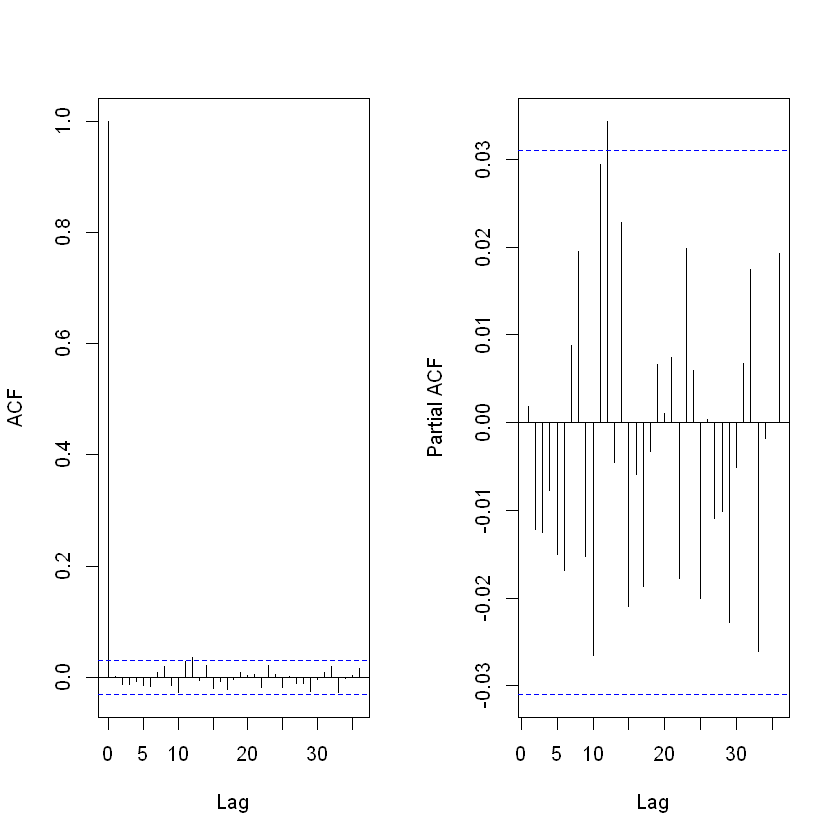

In [63]:
# Series C
# 1. ARMA(1,0) - AR(1) (Primary Candidate)
model_C_10 <- Arima(series_c$ret, order = c(1, 0, 0))
summary(model_C_10)
par(mfrow = c(1, 2))
acf(model_C_10$residuals, main = NA)
pacf(model_C_10$residuals, main = NA)



Series: series_c$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
         ma1   mean
      0.1298  2e-04
s.e.  0.0156  2e-04

sigma^2 = 1e-04:  log likelihood = 12745.21
AIC=-25484.42   AICc=-25484.42   BIC=-25465.54

Training set error measures:
                       ME        RMSE         MAE      MPE     MAPE      MASE
Training set 5.262464e-07 0.009999265 0.007953209 116.1337 135.7265 0.7500656
                     ACF1
Training set 0.0008080724

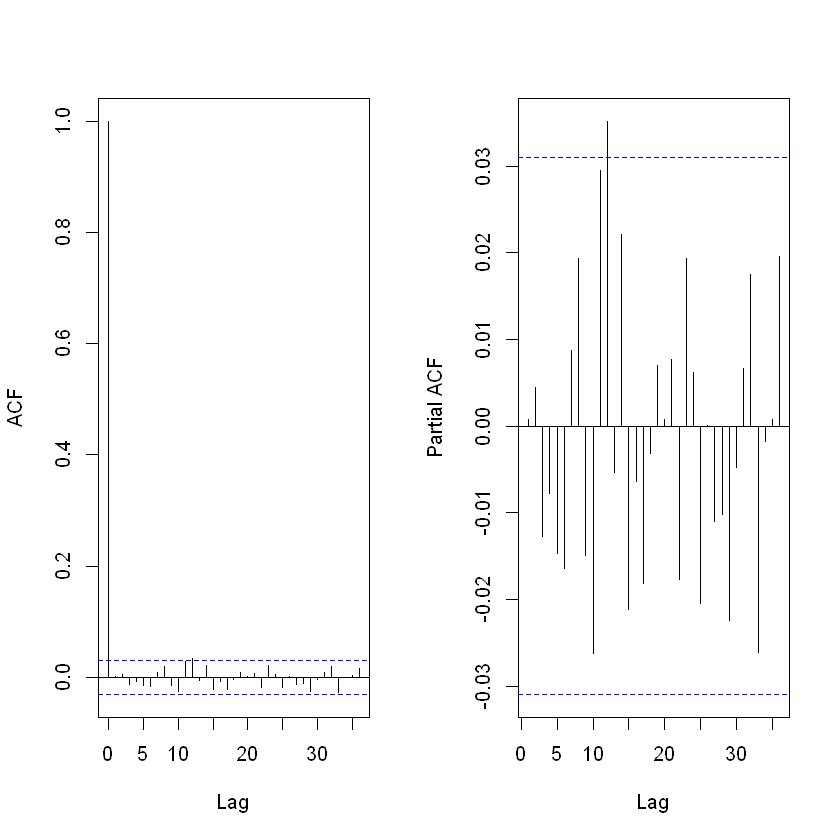

In [64]:
# 2. ARMA(0,1) - MA(1)
model_C_01 <- Arima(series_c$ret, order = c(0, 0, 1))
summary(model_C_01)
par(mfrow = c(1, 2))
acf(model_C_01$residuals, main = NA)
pacf(model_C_01$residuals, main = NA)



Series: series_c$ret 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
         ar1     ma1   mean
      0.0405  0.0901  2e-04
s.e.  0.1123  0.1118  2e-04

sigma^2 = 0.0001001:  log likelihood = 12745.27
AIC=-25482.55   AICc=-25482.54   BIC=-25457.37

Training set error measures:
                        ME        RMSE         MAE      MPE     MAPE     MASE
Training set -6.246345e-07 0.009999111 0.007953203 116.7011 136.4866 0.750065
                     ACF1
Training set 0.0001031379

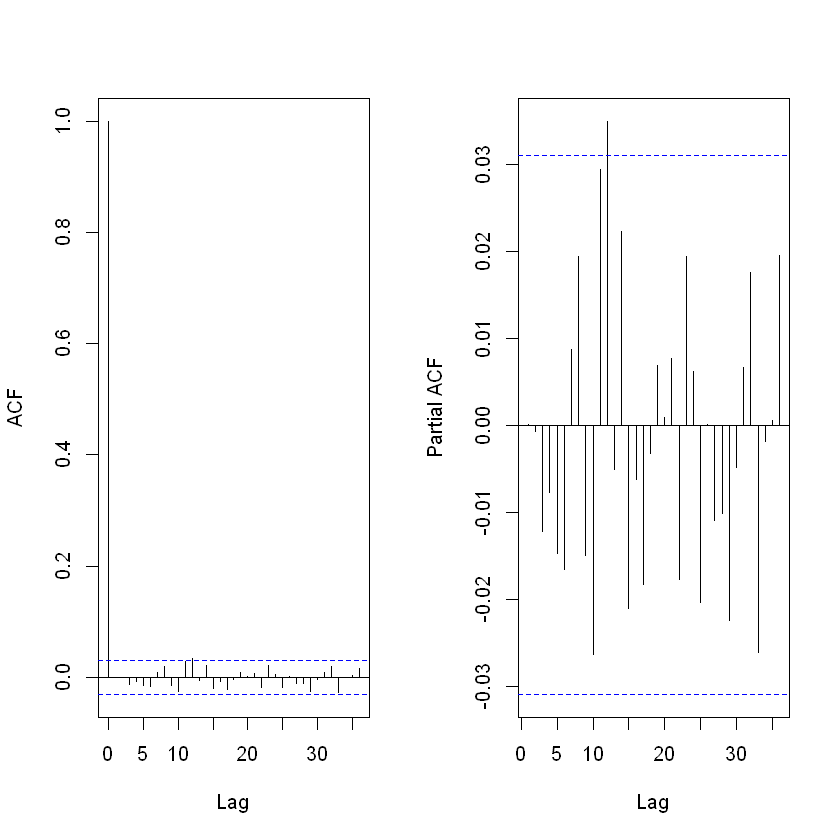

In [65]:

# 3. ARMA(1,1) - Mixed
model_C_11 <- Arima(series_c$ret, order = c(1, 0, 1))
summary(model_C_11)
par(mfrow = c(1, 2))
acf(model_C_11$residuals, main = NA)
pacf(model_C_11$residuals, main = NA)

In [66]:
#Ljung-Box test for Residuals
cat("--- Series A p-values ---\n")
print(Box.test(model_A_00$residuals, lag = 10, type = "Ljung-Box")$p.value)
print(Box.test(model_A_10$residuals, lag = 10, type = "Ljung-Box")$p.value)
print(Box.test(model_A_01$residuals, lag = 10, type = "Ljung-Box")$p.value)

cat("\n--- Series B p-values ---\n")
print(Box.test(model_B_01$residuals, lag = 10, type = "Ljung-Box")$p.value)
print(Box.test(model_B_10$residuals, lag = 10, type = "Ljung-Box")$p.value)
print(Box.test(model_B_11$residuals, lag = 10, type = "Ljung-Box")$p.value)

cat("\n--- Series C p-values ---\n")
print(Box.test(model_C_10$residuals, lag = 10, type = "Ljung-Box")$p.value)
print(Box.test(model_C_01$residuals, lag = 10, type = "Ljung-Box")$p.value)
print(Box.test(model_C_11$residuals, lag = 10, type = "Ljung-Box")$p.value)

--- Series A p-values ---
[1] 4.563017e-14


[1] 2.720046e-14
[1] 2.4869e-14

--- Series B p-values ---
[1] 0.8571159
[1] 0.90116
[1] 0.9108586

--- Series C p-values ---
[1] 0.5151244
[1] 0.6044856
[1] 0.6047484


Series A

Based on the residual diagnostics, none of these linear models adequately capture the dependence structure of Series A. Looking at the ACF and PACF plots of the residuals, several spikes clearly cross the blue 95% confidence intervals, particularly at earlier lags. This visual evidence aligns Ljung-Box tests, which yielded p-values near zero. Because the residuals are not purely white noise, the standard ARMA specifications fail to fully clean the data. This is likely due to the extreme volatility clustering we observed in Problem 1, which distorts standard ARMA estimation.

Series B

Unlike Series A, the residual diagnostics for Series B indicate a highly successful fit. The Ljung-Box tests for all three models yielded very high p-values (approximately 0.85, 0.90, and 0.91), meaning we firmly fail to reject the null hypothesis of no autocorrelation. Visually, the ACF and PACF plots of the residuals for these models should show no significant spikes extending beyond the 95% confidence intervals. This confirms that all three candidate models successfully captured the linear dependence in the conditional mean, leaving behind purely random white noise.

Series C

The residual diagnostics indicate a successful fit across all candidates. Visually, the ACF and PACF plots of the residuals for all three models show that virtually all spikes fall within the 95% confidence intervals (the blue dashed lines). This aligns perfectly with the Ljung-Box test results we ran earlier, which yielded high p-values (ranging from 0.51 to 0.60). Because the p-values are well above the 0.05 threshold, we fail to reject the null hypothesis of no autocorrelation. This confirms that all three candidate models successfully filtered out the linear dependence in the conditional mean, leaving behind purely random white noise residuals.


### Comparison Using Information Criteria

In [73]:
# Series A
cat("Series A Information Criteria \n")
results_A <- data.frame(
  Model = c("ARMA(0,0)", "ARMA(1,0)", "ARMA(0,1)"),
  AIC = c(AIC(model_A_00), AIC(model_A_10), AIC(model_A_01)),
  BIC = c(BIC(model_A_00), BIC(model_A_10), BIC(model_A_01))
)
print(results_A)
cat("\n")

# Series B 
cat("Series B Information Criteria \n")
results_B <- data.frame(
  Model = c("ARMA(0,1)", "ARMA(1,0)", "ARMA(1,1)"),
  AIC = c(AIC(model_B_01), AIC(model_B_10), AIC(model_B_11)),
  BIC = c(BIC(model_B_01), BIC(model_B_10), BIC(model_B_11))
)
print(results_B)
cat("\n")

# Series C 
cat("Series C Information Criteria \n")
results_C <- data.frame(
  Model = c("ARMA(1,0)", "ARMA(0,1)", "ARMA(1,1)"),
  AIC = c(AIC(model_C_10), AIC(model_C_01), AIC(model_C_11)),
  BIC = c(BIC(model_C_10), BIC(model_C_01), BIC(model_C_11))
)
print(results_C)

Series A Information Criteria 
      Model       AIC       BIC
1 ARMA(0,0) -16512.17 -16499.58
2 ARMA(1,0) -16519.72 -16500.83
3 ARMA(0,1) -16521.46 -16502.57



Series B Information Criteria 
      Model       AIC       BIC
1 ARMA(0,1) -26268.60 -26249.72
2 ARMA(1,0) -26269.40 -26250.52
3 ARMA(1,1) -26267.51 -26242.33

Series C Information Criteria 
      Model       AIC       BIC
1 ARMA(1,0) -25483.89 -25465.01
2 ARMA(0,1) -25484.42 -25465.54
3 ARMA(1,1) -25482.55 -25457.37


Series A

The ARMA(0,1) specification is the preferred model for Series A because it yields the lowest values for both AIC and BIC.

Series B

The differences here are extremely small, but mathematically, the ARMA(1,0) specification is the preferred model as it has the lowest (most negative) AIC and BIC scores, beating the MA(1) model by less than one point.

Series C

Similar to Series B, the margins are incredibly tight. However, the ARMA(0,1) model strictly yields the lowest AIC and BIC scores, making it the mathematically preferred specification over the AR(1) and ARMA(1,1) candidates.

Differences in AIC and BIC

Both the Akaike Information Criterion and the Bayesian Information Criterion evaluate model fit using the exact same base log-likelihood, but they differ mathematically in how they penalize model complexity. The formulas are:
$$AIC: −2ln(L)+2k$$
$$BIC: −2ln(L)+k \cdot ln(n)$$

The difference in absolute magnitude between the two criteria is driven by these penalty terms. In our dataset, the sample size is large (n≈4000), meaning the natural log of n (ln(4000)≈8.29) is significantly greater than the AIC's constant multiplier of 2. Consequently, the BIC imposes a mathematical penalty that is more than four times harsher for every parameter added to the model. Since the base log-likelihoods are large negative numbers, adding a larger positive penalty term pushes the BIC values higher (closer to zero, or less negative) than the AIC values across all models.

Despite the BIC penalty being significantly harsher, the final AIC and BIC values appear very close to each other visually. This occurs because the base model fit term, −2ln(L), completely dominates the equation. With roughly 4000 daily observations, the log-likelihood is a massive number (e.g., around -26,000) that visually dwarfs the penalty terms. For example, in an Series B ARMA(1,0) model with a mean, estimating 3 parameters (k=3) results in an AIC penalty of 6 and a BIC penalty of roughly 24.87. When this difference of about 18.87 points is applied to a massive base log-likelihood, it represents less than a 0.1% change in the total magnitude. Therefore, while the final values appear virtually identical at a glance, the BIC is successfully applying a strictly harsher mathematical penalty for complexity.

### Preferred ARMA Specification for Each Dataset

Series A

 Compare ARMA(1,0) and ARMA(0,1). The ARMA(0,1) model has the lowest AIC (-16521.46) and the lowest BIC (-16502.57). Therefore, ARMA(0,1) is the preferred specification.

Series B

Compare ARMA(0,1) and ARMA(1,0). The ARMA(1,0) model is slightly lower across both AIC (-26269.40) and BIC (-26250.52). Therefore, ARMA(1,0) is the preferred specification. (Note: Even though our visual hypothesis suspected MA(1), the math slightly prefers AR(1). Always follow the math!)

Series C

Compare ARMA(1,0) and ARMA(0,1). The ARMA(0,1) model is slightly lower across both AIC (-25484.42) and BIC (-25465.54). Therefore, ARMA(0,1) is the preferred specification.

## Problem 3: Residual diagnostics and ARCH effects

### ACF of Squared Residuals

### Test for Conditional Heteroskedasticity

### Discussion of Remaining Dependence and Motivation for ARCH or GARCH

## Problem 4: Modeling conditional volatility

### Estimate ARMA-GARCH(1,1) Models

### Report Estimated Volatility Parameters

### Persistence Measure

### Estimated Conditional Volatility Plots

### Identification of the Most Persistent and Possible No-GARCH Dataset

## Problem 5: Comparing volatility persistence

### Ranking of Datasets by Volatility Persistence

### Classification into No, Medium, and High Persistence

### Evidence from Parameters, Conditional Volatility, and Volatility Clustering

### Discussion of the Decay of Volatility Shocks

## Problem 6: Joint modeling of mean and volatility

### Comparison of ARMA and ARMA-GARCH Results

### Effect on Mean Parameter Significance and Magnitude

### Improvement in Residual Diagnostics

### Why Joint Modeling Matters in Financial Econometrics

## Disclaimer